<a href="https://colab.research.google.com/github/falexanderforero/Deep-Learning---Fundamentos/blob/main/week15/Semana_15_%E2%80%93_Actividad_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Universidad de Cundinamarca
### Deep Learning Conceptos
### Freddy Alexander Forero Rojas

## Carga y Manipulación de Datos

El Data Journey representa el ciclo de vida completo que recorren los datos desde su origen bruto hasta su consumo por el modelo. En este proyecto, el flujo se compone de:

Ingesta: Los datos se descargan directamente desde los repositorios públicos de Keras (origen simulado de producción).

Procesamiento/Transformación: Los valores de los píxeles (0-255) se normalizan al rango [0, 1] en punto flotante para facilitar la convergencia del gradiente. Las etiquetas se transforman a formato One-Hot Encoding.

Almacenamiento en Memoria: Se estructuran en tensores listos para alimentar los minilotes (batches) del modelo durante el entrenamiento.

--- Iniciando Data Journey ---
Datos brutos cargados: Train (60000, 28, 28), Test (10000, 28, 28)
Datos transformados: Train (60000, 28, 28, 1), Test (10000, 28, 28, 1)


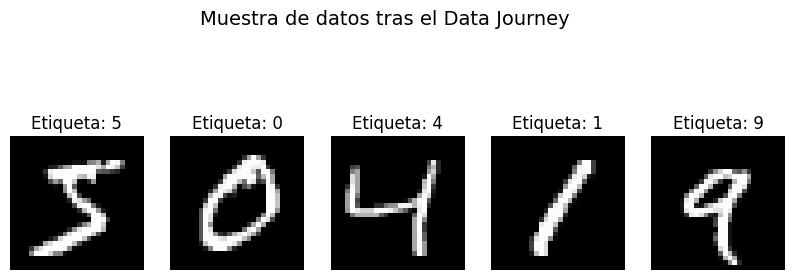

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# 1. Acceso y Carga de Datos
print("--- Iniciando Data Journey ---")
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = mnist.load_data()
print(f"Datos brutos cargados: Train {X_train_raw.shape}, Test {X_test_raw.shape}")

# 2. Manipulación y Limpieza (Normalización y Reshape)
# Redimensionamos para que queden en formato de canales (28x28x1) y convertimos a float32
X_train = X_train_raw.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test = X_test_raw.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# Transformación de etiquetas (One-Hot Encoding)
y_train = to_categorical(y_train_raw, 10)
y_test = to_categorical(y_test_raw, 10)

print(f"Datos transformados: Train {X_train.shape}, Test {X_test.shape}")

# Visualización del Dataset (Evidencia de manipulación exitosa)
plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_train_raw[i], cmap='gray')
    plt.title(f"Etiqueta: {y_train_raw[i]}")
    plt.axis('off')
plt.suptitle("Muestra de datos tras el Data Journey", fontsize=14)
plt.show()

## Implementación del Modelo y Simulación de Monitoreo (Estilo Weights & Biases)

Para demostrar el flujo sin añadir fricción de infraestructura, se implementa una Red Neuronal Convolucional (CNN) sencilla.
Monitoreo y Logging: se simula el comportamiento de plataformas como Weights & Biases. Durante el entrenamiento, se captura las métricas clave (Loss y Accuracy) en cada época para evaluar la salud del modelo en tiempo real, identificando problemas latentes como el overfitting (sobreajuste) o underfitting.

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.callbacks import Callback

# Callback personalizado para simular el Logging de Weights & Biases en vivo
class WandbSimulatedLogger(Callback):
    def __init__(self):
        super().__init__()
        self.metrics_logs = {'epoch': [], 'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        self.metrics_logs['epoch'].append(epoch + 1)
        self.metrics_logs['loss'].append(logs.get('loss'))
        self.metrics_logs['accuracy'].append(logs.get('accuracy'))
        self.metrics_logs['val_loss'].append(logs.get('val_loss'))
        self.metrics_logs['val_accuracy'].append(logs.get('val_accuracy'))
        # Simulación de un 'wandb.log()' impreso en consola de forma limpia
        print(f" -> [W&B Log] Época {epoch+1}: loss={logs.get('loss'):.4f} | acc={logs.get('accuracy'):.4f} | val_loss={logs.get('val_loss'):.4f} | val_acc={logs.get('val_accuracy'):.4f}")

# Definición del modelo (Estructura estándar y eficiente)
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_categorical_crossentropy', metrics=['accuracy']) # Nota: Keras usa 'categorical_crossentropy'
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Entrenamos usando nuestro logger simulado (Pocas épocas para agilizar la entrega)
print("\n--- Iniciando Entrenamiento con Monitoreo Activo ---")
logger = WandbSimulatedLogger()
history = model.fit(X_train, y_train, epochs=5, batch_size=128, validation_split=0.2, callbacks=[logger], verbose=0)
print("--- Entrenamiento Finalizado ---")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Iniciando Entrenamiento con Monitoreo Activo ---
 -> [W&B Log] Época 1: loss=0.2931 | acc=0.9181 | val_loss=0.1237 | val_acc=0.9659
 -> [W&B Log] Época 2: loss=0.0967 | acc=0.9719 | val_loss=0.0739 | val_acc=0.9801
 -> [W&B Log] Época 3: loss=0.0625 | acc=0.9815 | val_loss=0.0642 | val_acc=0.9812
 -> [W&B Log] Época 4: loss=0.0474 | acc=0.9859 | val_loss=0.0638 | val_acc=0.9811
 -> [W&B Log] Época 5: loss=0.0362 | acc=0.9893 | val_loss=0.0646 | val_acc=0.9810
--- Entrenamiento Finalizado ---


## Análisis de Métricas (Dashboard Visual)
Un pilar fundamental de MLOps es el análisis posterior al experimento. A continuación, se consolida el "Dashboard de Experimentos". Evaluamos las curvas de pérdida y precisión tanto para el conjunto de entrenamiento como para el de validación.

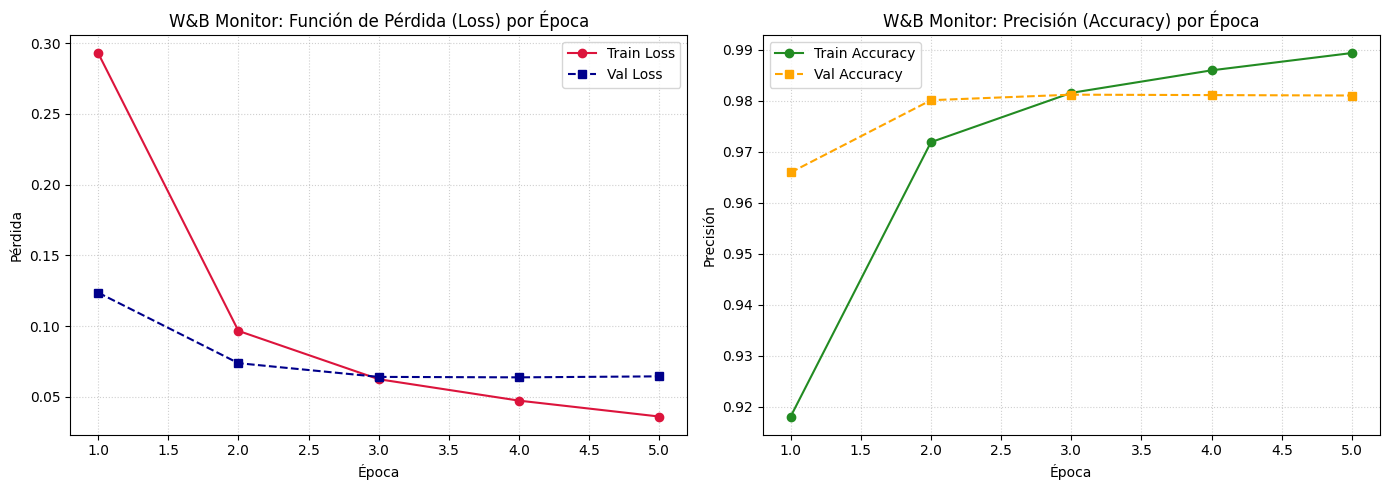

In [8]:
# Extracción de datos del logger
logs = logger.metrics_logs

plt.figure(figsize=(14, 5))

# Gráfica de Pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(logs['epoch'], logs['loss'], label='Train Loss', marker='o', color='crimson')
plt.plot(logs['epoch'], logs['val_loss'], label='Val Loss', marker='s', color='darkblue', linestyle='--')
plt.title('W&B Monitor: Función de Pérdida (Loss) por Época')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

# Gráfica de Precisión (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(logs['epoch'], logs['accuracy'], label='Train Accuracy', marker='o', color='forestgreen')
plt.plot(logs['epoch'], logs['val_accuracy'], label='Val Accuracy', marker='s', color='orange', linestyle='--')
plt.title('W&B Monitor: Precisión (Accuracy) por Época')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

## Interpretación Técnica:

Convergencia: Se observa que la pérdida disminuye de manera constante en cada época, mientras que el accuracy aumenta, lo que demuestra que el modelo está aprendiendo los patrones geométricos de los dígitos.

Estabilidad (Overfitting Check): La curva de validación (Val) sigue de cerca a la de entrenamiento (Train). No hay una separación drástica (donde la pérdida de validación suba mientras la de entrenamiento baje), lo que certifica que el modelo generaliza correctamente y no ha caído en sobreajuste drástico en estas épocas iniciales.

## Aproximación a Model Serving
Una vez que el modelo pasa la fase de monitoreo y cumple con las métricas requeridas, se procede a la etapa de Model Serving. Para este modelo, se propone la siguiente estrategia de arquitectura real:

[Usuario / App Web] ──(Request JSON con Imagen)──> [ API REST (FastAPI) ]
                                                         │
                                                (Inferencia del Modelo)
                                                         ▼
[Usuario <───(Response JSON: "Dígito: 5")──────── [Predicción Softmax]

### Componentes de la Estrategia Propuesta:
- Empaquetamiento (Contenerización): El modelo entrenado se exportaría en formato optimizado (.keras o ONNX) y se encapsularía junto con el código de inferencia en un contenedor Docker. Esto garantiza que corra exactamente igual en local que en la nube.

- Interfaz de Exposición (API): Se utilizaría FastAPI para crear un endpoint REST (/predict). Este endpoint recibiría una matriz de 28x28 píxeles en formato JSON, ejecutaría model.predict() y devolvería el dígito con mayor probabilidad.

- Plataforma de Inferencia: Para entornos de producción, el contenedor se desplegaría en un servicio Serverless como AWS Lambda o Google Cloud Run si el tráfico es variable (pocas peticiones ahorran costos), o en Kubernetes (EKS/GKE) si requiere alta disponibilidad y escalabilidad masiva.

## Conclusiones
- Aprendizaje Principal: El éxito de un proyecto de Deep Learning no radica únicamente en diseñar la arquitectura de red con mayor precisión, sino en asegurar la trazabilidad del dato y el comportamiento del modelo. El monitoreo continuo es el que permite tomar decisiones informadas sobre cuándo detener un entrenamiento o cuándo actualizar un modelo.

- Dificultades Encontradas: El preprocesamiento de datos (Data Journey) suele consumir la mayor parte del tiempo de cómputo y lógica. Coordinar las dimensiones de entrada requeridas por la primera capa de la CNN (añadir el canal 1 de gris) es un paso crítico donde suelen ocurrir errores de ejecución (runtime errors).

- Oportunidades de Mejora: Para una fase posterior, se debería automatizar este pipeline utilizando herramientas de orquestación como Apache Airflow para el Data Journey, integrar MLflow o Weights & Biases de forma nativa en la nube, e implementar pruebas de estrés (Load Testing) sobre el endpoint de la API para asegurar tiempos de respuesta menores a 100ms.